# Ejercicios Temas 3

## Ejercicio 3.1

• Calcula el valor Shapley para todos los jugadores i ∈ {1, 2, 3} en el siguiente juego cooperativo v(S):

| S        | ∅ | {1} | {2} | {3} | {1,2} | {1,3} | {2,3} | {1,2,3} |
|----------|---|-----|-----|-----|--------|--------|--------|----------|
| v(S)     | 0 | 1   | 1   | 1   | 2      | 2      | 2      | 3        |

• Calcula el valor Shapley para todos los jugadores i ∈{1, 2, 3} en el siguiente juego cooperativo v(S):

$$
v(S)= x_1 + 2x_2 + 3x_3
$$

,donde x_i son variables binarias siendo x_i = 1 si i ∈ S y 0 sino

• Calcula el valor Shapley para todos los jugadores i ∈ {1, 2, 3, 4, 5} en el siguiente juego cooperativo v(S):

$$
v(S)= x_1 + x_3 + 2x_4 + 3x_1 x_2 + 5x_2 x_5 - 10 x_1 x_2 x_4
$$

,donde x_i son variables binarias siendo x_i = 1 si i ∈ S y 0 sino

Pista: realiza un programa en Python que implemente una de las fórmulas vistas en clase

$$
\phi_i(V) = \sum_{S \subseteq D \setminus \{i\}} \frac{|S|!(|d|-1-|S|)!}{|d|!}\,[v(S \cup \{i\}) - v(S)]
$$


In [ ]:
from itertools import combinations
from math import factorial

def shapley(n, v, i):
    phi_i = 0.0
    N_minus_i = set(range(n)) - {i}

    for size in range(n):
        for S in combinations(N_minus_i, size):
            S = set(S)
            S_union_i = S | {i}
            s = len(S)

            weight = (factorial(s) * factorial(n - s - 1)) / factorial(n)
            marginal_contribution = v(S_union_i) - v(S)
            phi_i += weight * marginal_contribution

    return phi_i



In [ ]:
# Caso 1: tabla fija
def v1(S):
    S_sorted = tuple(sorted(S))
    valores = {
        (): 0,
        (0,): 1,
        (1,): 1,
        (2,): 1,
        (0, 1): 2,
        (0, 2): 2,
        (1, 2): 2,
        (0, 1, 2): 3
    }
    return valores.get(S_sorted, 0)

#Caso 2: primera funcion
def v2(S):
    valor = 0
    if 0 in S:
        valor += 1
    if 1 in S:
        valor += 2
    if 2 in S:
        valor += 3
    return valor


#Caso 3: segunda funcion
def v3(S):
    x1 = 1 if 0 in S else 0
    x2 = 1 if 1 in S else 0
    x3 = 1 if 2 in S else 0
    x4 = 1 if 3 in S else 0
    x5 = 1 if 4 in S else 0

    return x1 + x2 + 2*x4 + 3*x1*x2 + 5*x3*x4 - 10*x1*x2*x3

In [ ]:
print("JUEGO 1: Tabla de valores")
print("-" * 50)
n1 = 3
for i in range(n1):
    phi = shapley(n1, v1, i)
    print(f"φ_{i+1}(v) = {phi:.4f}")
print(f"Suma: {sum(shapley(n1, v1, i) for i in range(n1)):.4f}\n")

print("JUEGO 2: v(S) = x1 + 2x2 + 3x3")
print("-" * 50)
n2 = 3
for i in range(n2):
    phi = shapley(n2, v2, i)
    print(f"φ_{i+1}(v) = {phi:.4f}")
print(f"Suma: {sum(shapley(n2, v2, i) for i in range(n2)):.4f}\n")

print("JUEGO 3: v(S) = x1 + x2 + 2x4 + 3x1x2 + 5x3x4 - 10x1x2x3")
print("-" * 50)
n3 = 5
for i in range(n3):
    phi = shapley(n3, v3, i)
    print(f"φ_{i+1}(v) = {phi:.4f}")
print(f"Suma: {sum(shapley(n3, v3, i) for i in range(n3)):.4f}")

JUEGO 1: Tabla de valores
--------------------------------------------------
φ_1(v) = 1.0000
φ_2(v) = 1.0000
φ_3(v) = 1.0000
Suma: 3.0000

JUEGO 2: v(S) = x1 + 2x2 + 3x3
--------------------------------------------------
φ_1(v) = 1.0000
φ_2(v) = 2.0000
φ_3(v) = 3.0000
Suma: 6.0000

JUEGO 3: v(S) = x1 + x2 + 2x4 + 3x1x2 + 5x3x4 - 10x1x2x3
--------------------------------------------------
φ_1(v) = -0.8333
φ_2(v) = -0.8333
φ_3(v) = -0.8333
φ_4(v) = 4.5000
φ_5(v) = 0.0000
Suma: 2.0000


## Ejercicio 3.3

In [1]:
!pip -q install ucimlrepo lime shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from lime.lime_tabular import LimeTabularExplainer
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml
from ucimlrepo import fetch_ucirepo
import numpy as np
from sklearn.metrics import accuracy_score
import warnings
import matplotlib.pyplot as plt
import os

Obtenenmos el dataset

In [3]:
adult = fetch_ucirepo(id=2)

data = adult.data

X = data.features
y = data.targets["income"]

print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
dtypes: int64(6), object(8)
memory usage: 5.2+ MB
None


Así como se puede ver en la tabla anterior, tenemos valores nulos entre nustros datos, así que vamos a tener que tratarlos.
Además, nos hemos fijado que el dataset tiene valores con un interrogante (?) así como podemos ver en el dato 14:

In [4]:
X.iloc[14]

,14
age,40
workclass,Private
fnlwgt,121772
education,Assoc-voc
education-num,11
marital-status,Married-civ-spouse
occupation,Craft-repair
relationship,Husband
race,Asian-Pac-Islander
sex,Male


Al saber esto, nos sugieren dos opciones:
- Eliminar todas las filas que tienen valores con interrogantes y valores nulos.
- Imputar esos valores para conservar más datos.

In [5]:
print(f"Número de datos del dataset: {len(X)}" )
print(f"Número de datos con nulos en X: {X.isnull().any(axis=1).sum()}")
print(f"Número de datos con nulos en y: {y.isnull().sum()}")
print(f"Número de datos con '?' en X: {(X == '?').any(axis=1).sum()}")
print(f"Número de datos con '?' en y: {(y == '?').sum()}")

null_rows = X.isnull().any(axis=1)
qmark_rows = (X == '?').any(axis=1)
intersection_mask = null_rows & qmark_rows
print(f"Filas con nulos y interrogantes: {intersection_mask.sum()}")

Número de datos del dataset: 48842
Número de datos con nulos en X: 1221
Número de datos con nulos en y: 0
Número de datos con '?' en X: 2399
Número de datos con '?' en y: 0
Filas con nulos y interrogantes: 0


Con esto podemos ver que solo alrededor del 7% del dataset es el que tiene los interrogantes o datos nulos. Por tanto, para no variar el entrenamiento introduciendo sesgo artificial, vamos a eliminar esas filas "infectadas"

In [6]:
X = X.copy()
y = y.copy()

# Reemplazamos '?' por NaN
X.replace('?', np.nan, inplace=True)

# Identificamos índices
indices_a_borrar = X[X.isnull().any(axis=1)].index

# Borramos ambos
X.drop(indices_a_borrar, inplace=True)
y.drop(indices_a_borrar, inplace=True)

# Resetear índices
X.reset_index(drop=True, inplace=True)
y.reset_index(drop=True, inplace=True)

In [7]:
print(f"Número de datos del dataset: {len(X)}" )
print(f"Número de datos del dataset: {len(y)}" )

Número de datos del dataset: 45222
Número de datos del dataset: 45222


Ahora tenemos que verificar que la columna objetivo se encuetra perfecta para realizar el `RandomForest`. En principio, nosotros sabemos que la columna objetivo es binaria (<=50K o >50K), pero a continuación observamos un error:

In [8]:
classes, counts = np.unique(y, return_counts=True)

for c, n in zip(classes, counts):
    print(f"{c}: {n}")

<=50K: 22654
<=50K.: 11360
>50K: 7508
>50K.: 3700


Algunos objetivos se encuentran sucios (con un punto al final), así que lo que tenemos que hacer es limpiarlo eliminando el punto

In [9]:
y = y.str.rstrip('.')

Una vez eliminado estos errores, podemos comprobar que se ha realizado correctamente.

In [10]:
classes, counts = np.unique(y, return_counts=True)

for c, n in zip(classes, counts):
    print(f"{c}: {n}")

<=50K: 34014
>50K: 11208


Además, nos hemos fijado que hay dos columnas que representan los mismo pero de distinta forma:
- `education` : Categórica (Bachelors, HS-grad, etc.)
- `education-num`: Numérica (13, 9, etc.)
Por este motivo, podemos eliminar una columna y evitar comprobaciones innecesarias.

In [11]:
if 'education-num' in X.columns:
    X.drop('education-num', axis=1, inplace=True)

X.head()

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


Hacemos One-Hot encodding a todas las columnas categóricas

In [12]:
X = pd.get_dummies(X, drop_first=True)

Dividimos el dataset

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)

Entrenamos el `RandomForest`

In [14]:
model = RandomForestClassifier(n_estimators=100, random_state=10)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=10)

Observamos los resultados del entrenamiento:

In [15]:
y_pred_train = model.predict(X_train)

accuracy = accuracy_score(y_train, y_pred_train)
print("Accuracy:", accuracy)

Accuracy: 0.9999723581280925


In [16]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8477611940298507


### (a) Características más importantes
Calcule las atribuciones locales de las 200 primeras instancias del conjunto de datos de test (X_test[:200]). Llamaremos exp_test a estas muestras, ya que son las muestras que se están explicando. Utilice los siguientes métodos (y ten en cuenta que KernelSHAP y LIME pueden tardar un poco en ejecutarse). A partir de estos gráficos de resumen, ¿cuáles son las características más importantes
según cada método?

Vamos a definir las 200 instancias que vamos a explicar

In [17]:
exp_test = X_test.iloc[:200].copy()

#### TreeSHAP

In [18]:
# Explainer específico para árboles
explainer_tree = shap.TreeExplainer(model)

# Atribuciones para las 200 instancias
shap_values_tree = explainer_tree.shap_values(exp_test)

# Elegimos la clase positiva
shap_values_tree_pos = shap_values_tree[:, :, 1]   # clase positiva

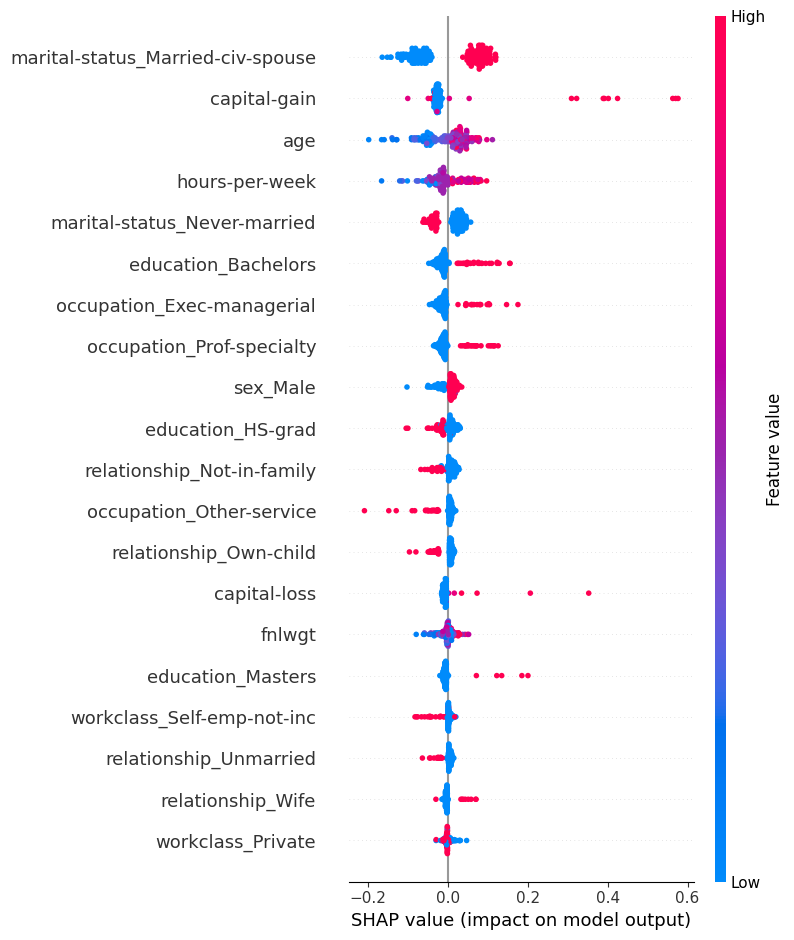

In [20]:
# Summary plot
shap.summary_plot(shap_values_tree_pos, exp_test, plot_type="dot")


Como estos tipos de graficos son difíciles de interpretar a primera vista, hay que tener en cuenta que:
- **Eje Y**: las características están ordenadas por importancia global descendente, siendo la variable superior la más influyente.
- **Eje X**: indica cuánto empuja cada característica la predicción. Valores **positivos** (a la derecha del 0) aumentan la probabilidad de ganar >50K anuales; valores **negativos** (a la izquierda) la disminuyen.
- **Color**: representa el valor real de la característica para esa persona. **Rojo** es un valor alto, **Azul** es un valor bajo.

En cuanto a los resultados del `TreeShap`, estas son las variables más influyentes:
- `marital-status_Married-civ-spouse` (Estar casado con cónyuge civil): es la variable más determinante para el modelo. Se observa una clara separación. Los puntos rojos (personas casadas) están concentrados a la derecha, teniendo un impacto muy positivo en la probabilidad de altos ingresos. Los puntos azules (no casados en esta categoría) se acumulan a la izquierda, reduciendo la probabilidad
- `capital-gain` (Ganancias de capital): la mayoría de los puntos son azules (valor 0) y se agrupan ligeramente a la izquierda del 0. Sin embargo, los puntos rojos (personas con ganancias de capital) se disparan hacia el extremo derecho. Esto indica que tener ganancias de capital es un indicador extremadamente fuerte de riqueza, aunque no tenerlas no penaliza tanto como no estar casado.
- `age`: los puntos azules (personas jóvenes) están claramente situados a la izquierda (impacto negativo). A medida que el color se torna púrpura o rojo (mayor edad), los puntos se desplazan a la derecha. Esto refleja que la experiencia y la antigüedad laboral son factores clave para superar la barrera de los 50K anuales.
- `Hours-per-week` (Horas por semana): trabajar pocas horas (puntos azules) empuja la predicción hacia la izquierda (menos ingresos), mientras que trabajar muchas horas (puntos rojos) la empuja hacia la derecha (más ingresos).
- `marital-status_Never-married` (Nunca casado): los puntos rojos (personas solteras que nunca se han casado) se concentran a la izquierda del eje central, disminuyendo la probabilidad de ganar >50K. Los puntos azules (no pertenecer a esta categoría) tienen un efecto positivo o neutro.

#### KernelSHAP

In [21]:
# 1) Background para aproximar la distribución de los datos
background = X_train.sample(50, random_state=10)

# 2) Función modelo: devuelve probabilidades de clase
f = lambda x: model.predict_proba(x)

# 3) Crear explainer y calcular SHAP values
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # oculta warnings de shap
    explainer_kernel = shap.KernelExplainer(f, background)
    shap_values_kernel = explainer_kernel.shap_values(exp_test)

    # 4) Elegir la clase positiva
    shap_values_kernel_pos = shap_values_kernel[:, :, 1]  # (n_muestras, n_features)

  0%|          | 0/200 [00:00<?, ?it/s]

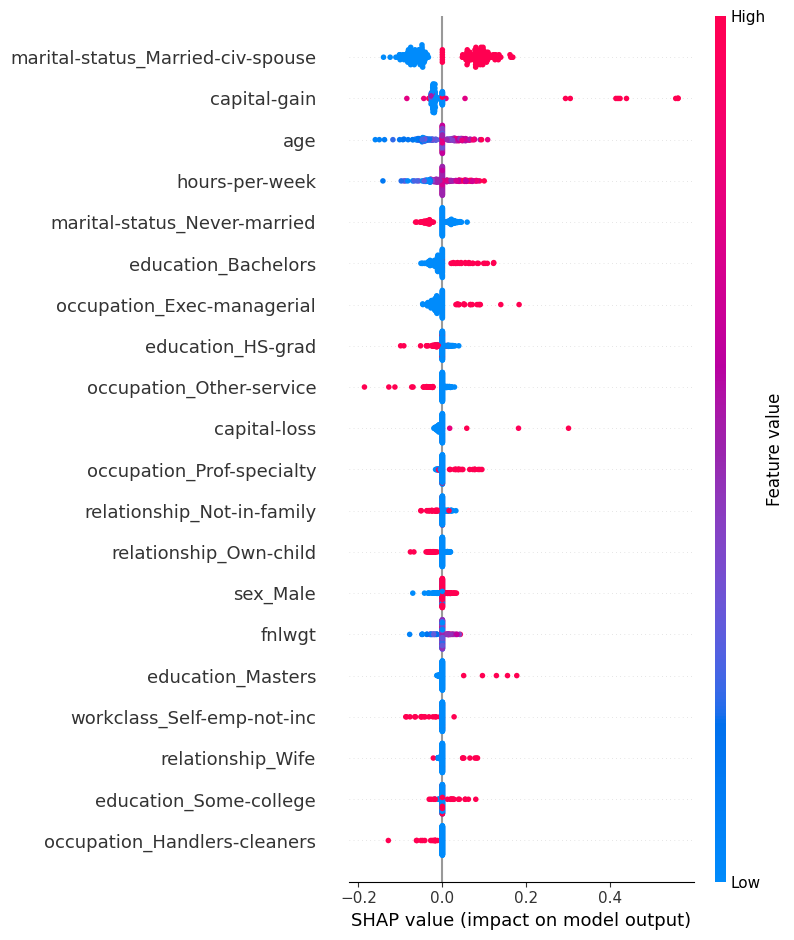

In [22]:
# Summary plot
shap.summary_plot(shap_values_kernel_pos, exp_test, plot_type="dot")

Al comparar los resultados de KernelSHAP con los de TreeSHAP, observamos que las características más importantes y la dirección de su impacto son consistentes entre ambos métodos (`marital-status_Married-civ-spouse`, `capital-gain`, `age`, `hours-per-week` y `marital-status_Never-married`). Esto es esperable, ya que ambos métodos buscan estimar los mismos valores teóricos (Valores Shapley). Las pequeñas variaciones observadas en comparación con el anterior modelo se deben a que KernelSHAP es una aproximación basada en muestreo, mientras que TreeSHAP es un cálculo exacto para este tipo de modelo.

Aunque no esten entre las 5 más importantes, cabe destacar las variables `education_Bachelors` y `occupation_Exec-managerial`, ya que actúan como indicadores positivos, confirmando que poseer un título universitario y desempeñar una profesión de alto nivel son factores estructurales clave para superar el umbral de los 50K anuales.

#### LIME

In [23]:
# Definir explainer de LIME
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['<=50K', '>50K'],   # adapta a tus etiquetas
    discretize_continuous=True,
    mode='classification'
)

n_features = X_train.shape[1]
n_samples = exp_test.shape[0]

# Matriz para guardar las atribuciones de LIME
lime_values = np.zeros((n_samples, n_features))

with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)

    # Explicamos cada instancia de exp_test
    for i in range(n_samples):
        exp = lime_explainer.explain_instance(
            data_row=exp_test.iloc[i].values,
            predict_fn=model.predict_proba,
            num_features=n_features  # para tener todas las features
        )
        # exp.local_exp[1] es una lista de (indice_feature, peso)
        for feat_idx, weight in exp.local_exp[1]:
            lime_values[i, feat_idx] = weight

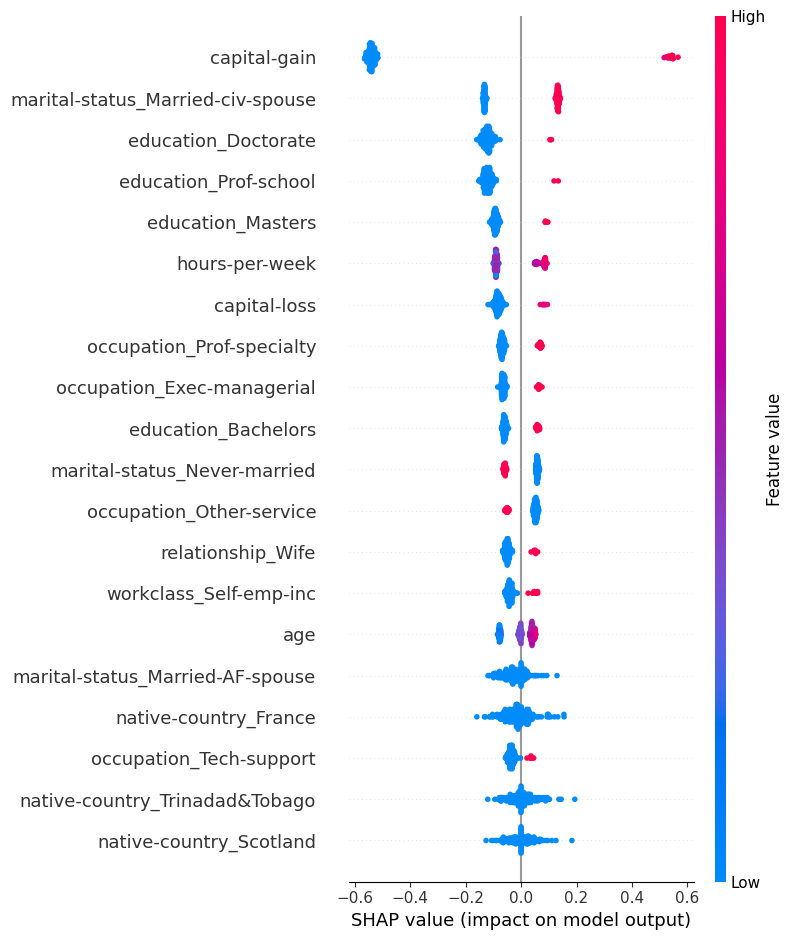

In [24]:
# Aunque no son SHAP, podemos usar summary_plot para visualizar
shap.summary_plot(lime_values, exp_test, plot_type="dot")


En esta gráfica se puede ver una principal diferencia con los modelos SHAP, y es que LIME declara como más importante, y con bastante diferencia, a la variable `capital-gain`. Esto lo podemos saber por la distancia que hay entre los puntos rojos y azules con el 0. Además, coinciden en que la variable `marital-status_Married-civ-spouse` es importante.

En cambio, LIME prioriza más la educación como tener un Posgrado Profesional, Doctorado o Máster.

## (b) Características Edad y Horas por semana
Visualice las atribuciones de cada método para las características "Edad" y "Horas por semana" con un gráfico de dispersión, colocando el valor de la característica en el eje x y la atribución de la característica en el eje y. Utilice la biblioteca matplotlib para generar los gráficos. Sobre la base de estos gráficos, ¿qué observaciones puede hacer sobre cómo se relacionan estas características con la predicción de ingresos del modelo?

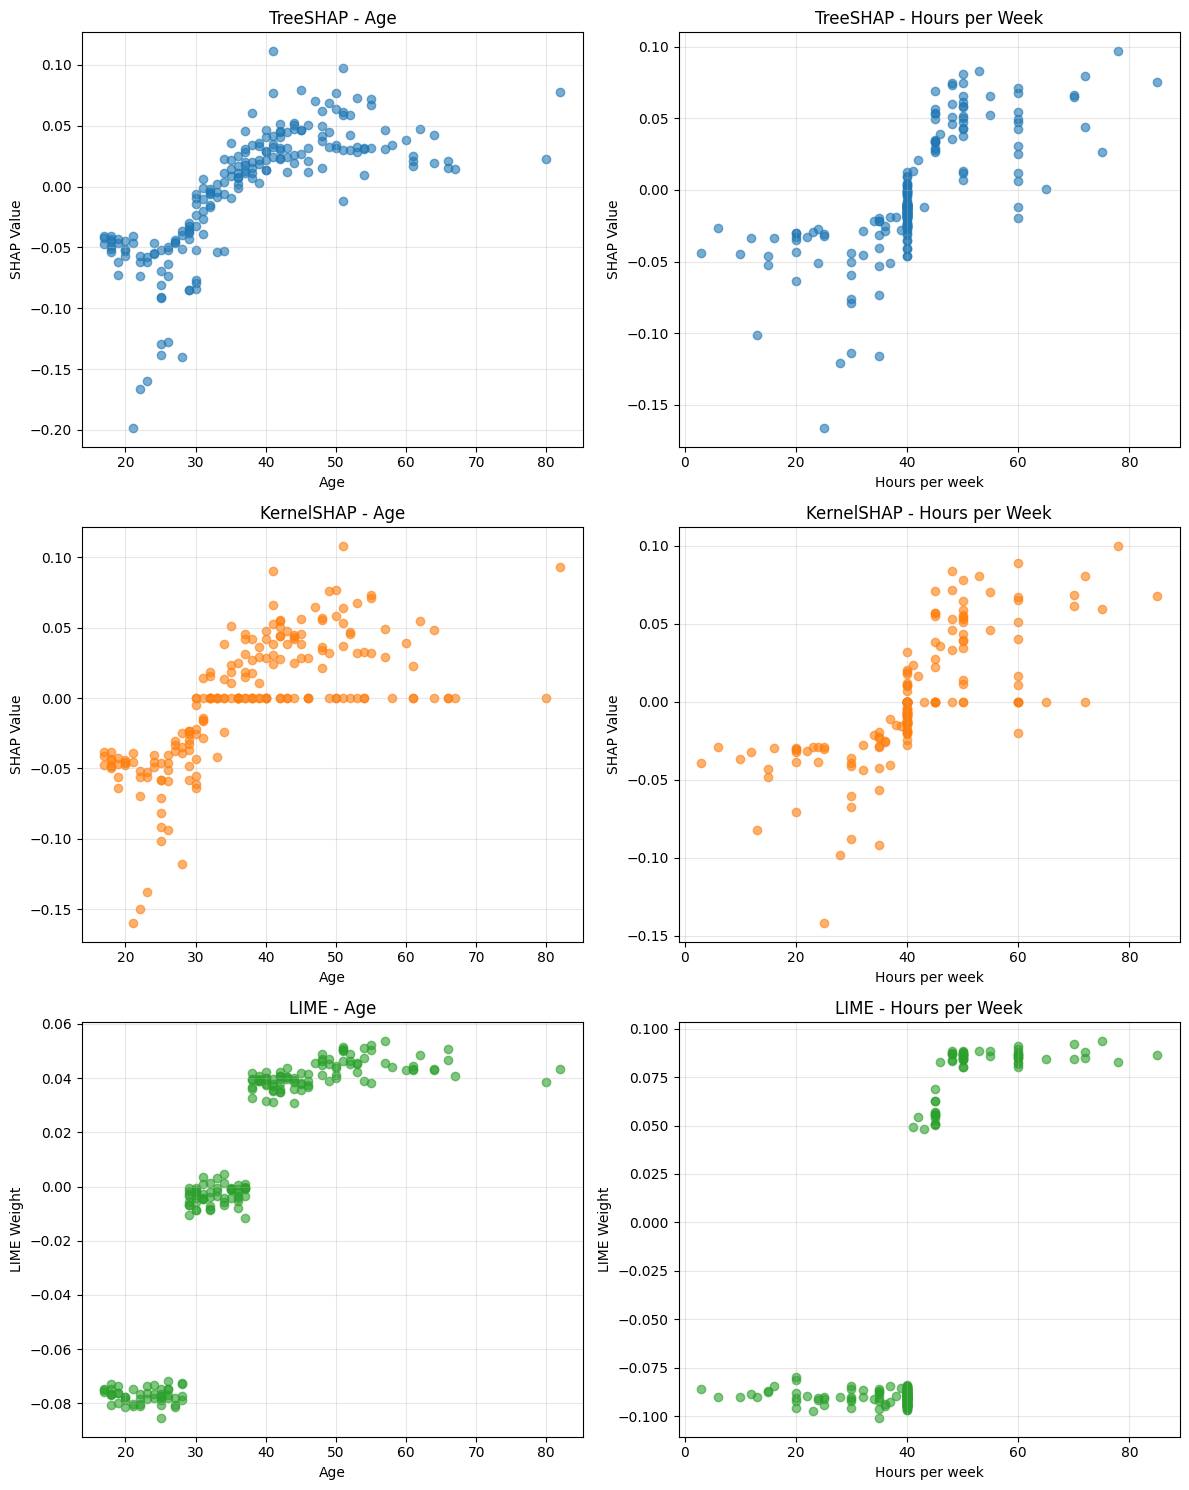

In [25]:
# --- 1. PREPARACIÓN DE DATOS (Igual que tu código) ---

# Vector de valores reales
age_values   = exp_test["age"].values
hours_values = exp_test["hours-per-week"].values

# Índices de las columnas
age_idx   = X_test.columns.get_loc("age")
hours_idx = X_test.columns.get_loc("hours-per-week")

# Extraemos atribuciones
age_shap_tree   = shap_values_tree_pos[:, age_idx]
hours_shap_tree = shap_values_tree_pos[:, hours_idx]

age_shap_kernel   = shap_values_kernel_pos[:, age_idx]
hours_shap_kernel = shap_values_kernel_pos[:, hours_idx]

age_lime   = lime_values[:, age_idx]
hours_lime = lime_values[:, hours_idx]

# Ajustamos el tamaño para 3 filas (más alto)
plt.figure(figsize=(12, 15))

# TreeSHAP
# Columna 1: Age
plt.subplot(3, 2, 1)
plt.scatter(age_values, age_shap_tree, alpha=0.6, color='tab:blue')
plt.xlabel("Age")
plt.ylabel("SHAP Value")
plt.title("TreeSHAP - Age")
plt.grid(alpha=0.3)

# Columna 2: Hours
plt.subplot(3, 2, 2)
plt.scatter(hours_values, hours_shap_tree, alpha=0.6, color='tab:blue')
plt.xlabel("Hours per week")
plt.ylabel("SHAP Value")
plt.title("TreeSHAP - Hours per Week")
plt.grid(alpha=0.3)

# KernelSHAP
# Columna 1: Age
plt.subplot(3, 2, 3)
plt.scatter(age_values, age_shap_kernel, alpha=0.6, color='tab:orange')
plt.xlabel("Age")
plt.ylabel("SHAP Value")
plt.title("KernelSHAP - Age")
plt.grid(alpha=0.3)

# Columna 2: Hours
plt.subplot(3, 2, 4)
plt.scatter(hours_values, hours_shap_kernel, alpha=0.6, color='tab:orange')
plt.xlabel("Hours per week")
plt.ylabel("SHAP Value")
plt.title("KernelSHAP - Hours per Week")
plt.grid(alpha=0.3)

# LIME
# Columna 1: Age
plt.subplot(3, 2, 5)
plt.scatter(age_values, age_lime, alpha=0.6, color='tab:green')
plt.xlabel("Age")
plt.ylabel("LIME Weight")
plt.title("LIME - Age")
plt.grid(alpha=0.3)

# Columna 2: Hours
plt.subplot(3, 2, 6)
plt.scatter(hours_values, hours_lime, alpha=0.6, color='tab:green')
plt.xlabel("Hours per week")
plt.ylabel("LIME Weight")
plt.title("LIME - Hours per Week")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

En el gráfico anterior, podemos observar la distribución de las variables `age` y `hours-per-week` en cada modelo. A primera vista se ve claramente como ambas tienen una correlación positiva con la predicción de ingresos anuales de >50K.

En cuanto a la variable `age` tanto en **TreeSHAP** como en **KernelSHAP**, se observa una relación no lineal clara. Los jóvenes (< 30 años) tienen valores de SHAP  negativos, indicando que ser joven disminuye la probabilidad de que el modelo prediga que la persona gana más de 50k. Los adultos (30 - 50 años) la atribución sube rápidamente y se vuelve positiva. Esto tiene sentido socioeconómico, a medida que se gana experiencia, los ingresos suelen aumentar. Finalmente, los mayores (> 50 años), la curva se aplana o se satura. Tener más de 50 o 60 años sigue contribuyendo positivamente, pero el incremento marginal de la probabilidad ya no es tan pronunciado como el salto de los 20 a los 40 años. En **LIME**, se observa cómo el gráfico no es una curva continua, sino que parece una "escalera" con tres niveles claros. Esto ocurre porque la implementación estándar de LIME tabular discretiza las variables continuas en rangos (bins). LIME está tratando la edad por grupos:
- Un grupo joven (aprox. < 28) con peso negativo.
- Un grupo intermedio (aprox. 28-38) con peso cercano a cero.
- Un grupo mayor (aprox. > 38) con peso positivo.

Por lo que hace la variable `hours-per-week`, en **SHAP** se puede observar un punto de inflexión muy claro alrededor de las 40 horas.
- **< 40 horas**: Las atribuciones son mayoritariamente negativas. Trabajar a tiempo parcial reduce la probabilidad de ser clasificado como de "altos ingresos".
- **> 40 horas**: Las atribuciones se vuelven positivas. Trabajar horas extra aumenta la probabilidad de la clase ">50K".

Además, en **TreeSHAP** y **KernelSHAP** hay cierta varianza vertical (puntos a la misma altura en X tienen diferente Y). Esto sugiere interacciones con otras variables, por ejemplo, trabajar muchas horas con bajo nivel educativo podría no subir tanto la probabilidad como trabajar esas mismas horas con un doctorado.

En el comportamiento con **LIME** volvemos a ver el efecto de la discretización, dividiendo esta variable en dos grandes bloques (tiempo completo vs. parcial) sin mostrar la continuidad de los cambios marginales.

## (c) Explicación local de la instancia 1
Visualice las atribuciones de cada método para la muestra con índice 1 en el conjunto de prueba (`X_test.iloc[1]`) mediante un gráfico de barras, con los nombres de las características en el eje y, y las atribuciones de las características en el eje x . A partir de las atribuciones TreeSHAP, describa una característica que contribuya de forma muy positiva a la predicción de esta muestra y otra que tenga una contribución negativa importante

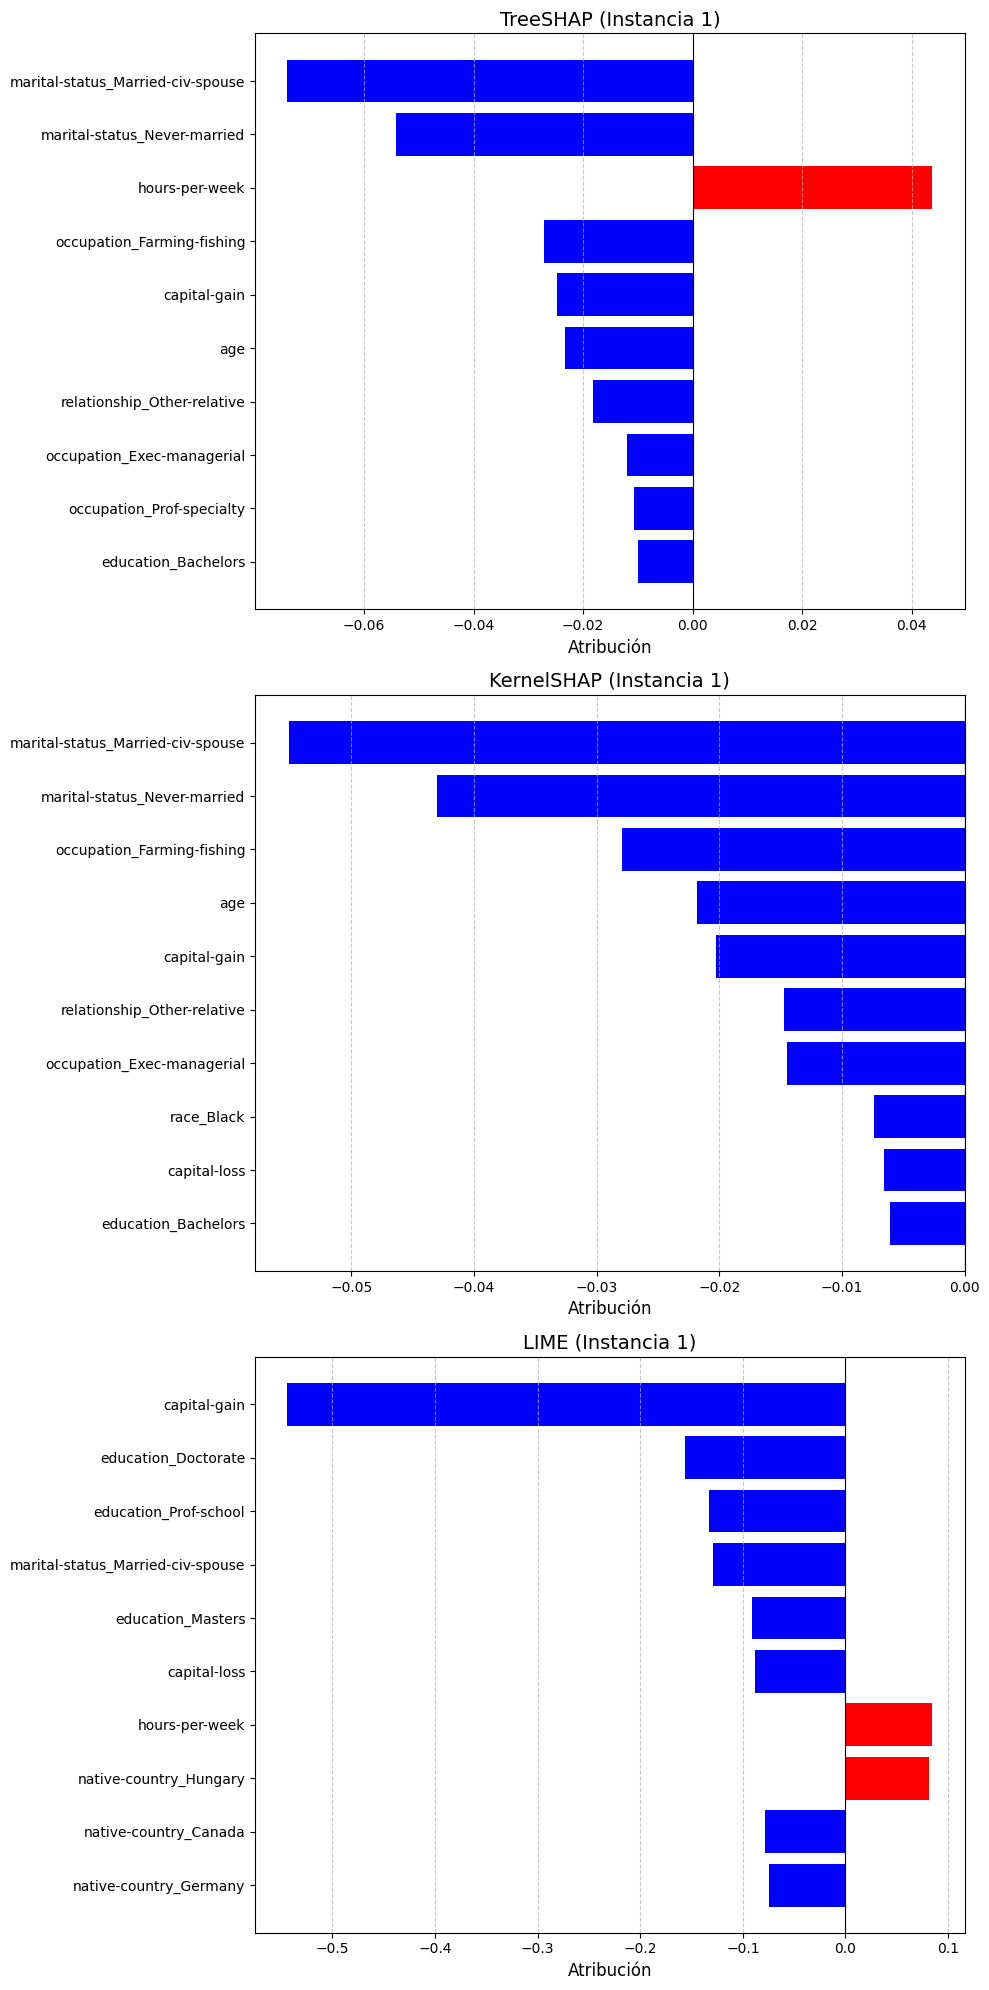

In [26]:
idx_instance = 1  # Índice de la muestra a explicar
feature_names = exp_test.columns

# Diccionario con los datos de cada método
# Asegúrate de tener estas variables cargadas
methods = {
    'TreeSHAP': shap_values_tree_pos,
    'KernelSHAP': shap_values_kernel_pos,
    'LIME': lime_values
}

# CONFIGURACIÓN VERTICAL
# nrows=3, ncols=1 -> Una columna con 3 filas
fig, axes = plt.subplots(3, 1, figsize=(10, 20))
plt.subplots_adjust(hspace=0.4) # Espacio vertical entre gráficos

# Iterar sobre cada método
for i, (method_name, values_matrix) in enumerate(methods.items()):
    ax = axes[i] # Seleccionar el eje correspondiente (ahora es un índice simple)

    # Extraer valores para la instancia
    vals = values_matrix[idx_instance]

    vals = np.array(vals)
    if vals.ndim > 1:
        if vals.shape[1] == 1: vals = vals.flatten()
        else: vals = vals[:, -1] # Clase positiva

    # Recorte de seguridad
    min_len = min(len(vals), len(feature_names))
    vals = vals[:min_len]
    current_features = feature_names[:min_len]

    df_vis = pd.DataFrame({'Feature': current_features, 'Attribution': vals})
    df_vis['Abs'] = df_vis['Attribution'].abs()
    df_vis = df_vis.sort_values('Abs', ascending=True).tail(10) # Top 10

    colors = ['red' if x > 0 else 'blue' for x in df_vis['Attribution']]
    ax.barh(df_vis['Feature'], df_vis['Attribution'], color=colors)

    # Estética
    ax.set_title(f"{method_name} (Instancia {idx_instance})", fontsize=14)
    ax.set_xlabel("Atribución", fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.axvline(0, color='black', linewidth=0.8) # Línea central

plt.tight_layout()
plt.show()

Por lo que hace en el gráfico de **TreeSHAP**, podemos identificar las contribuciones de la siguiente manera:
- **Contribución Positiva**: la variable `hours-per-week`. Es la única variable con contribución positiva en el gráfico. Esto significa que está empujando la predicción del modelo hacia la clase positiva (ingresos >50K). Esto sugiere que esta persona trabaja una cantidad de horas que el modelo asocia con mayores ingresos (probablemente horas extra o jornada completa).
- **Contribución Negativa**: la variable `marital-status_Married-civ-spouse` es la que tiene mayor contribución negativa. Al ser una variable con codificación One-Hot, esto significa que el valor que tiene esta persona para esa columna específica está reduciendo drásticamente su probabilidad de tener ingresos altos según el modelo. Dado que en este conjunto de datos estar casado suele correlacionar positivamente con ingresos altos, es probable que esta persona no esté casada, y esa ausencia de matrimonio es lo que el modelo penaliza con un valor SHAP negativo.

Por otro lado, **KernelSHAP** muestra resultados exclusivamente negativos en el top 10 visualizado y no detecta la contribución positiva de las horas de trabajo. Aún así, coincide con **TreeSHAP** en señalar `marital-status_Married-civ-spouse` como la variable que contribuye más negativamente.

Finalmente, en **LIME**, observamos una discrepancia en la variable que empuja a la clase negativa. LIME asigna una importancia negativa muy grande a `capital-gain`, una variable que en **TreeSHAP** y **KernelSHAP** aparece con mucha menos relevancia. Esto demuestra la inestabilidad local de LIME; al ajustar un modelo lineal simple alrededor de la instancia, a veces sobreestima el peso de ciertas características si el entorno local es muy no lineal.

Vamos a ver que valores tienen las variables que mas influencia tienen:

In [27]:
# Lista con las variables más influyentes
features_top = [
    "hours-per-week",
    "marital-status_Married-civ-spouse",
    "marital-status_Never-married"
]

# Imprimir los valores reales para la instancia 1
print(X_test.iloc[1][features_top])

hours-per-week                          72
marital-status_Married-civ-spouse    False
marital-status_Never-married          True
Name: 23202, dtype: object


- `hours-per-week`: 72. Esto confirma por qué es la variable más positiva. El modelo premia enormemente el esfuerzo extra, y 72 horas es un valor extremo que empuja la probabilidad de ganar >50k hacia arriba con mucha fuerza.
- `marital-status`: **Never-married** (True) / **Married** (False). Al ser `Married-civ-spouse` = **False**, pierde el "bonus" estadístico que suelen tener las personas casadas en este dataset. Al ser `Never-married` = **True**, recibe una penalización adicional, ya que estadísticamente este grupo tiende a tener menores ingresos familiares que los casados. De ahí que ambas barras sean negativas.

## (d) Análisis de sensibilidad de KernelSHAP
Un parámetro importante para KernelSHAP es el número de muestras (el argumento nsamples en la función la función shap values() de KernelExplainer). Si se utilizan más muestras, mejorará la calidad del resultado final de atribución de características, pero es más costoso. En las partes anteriores de este problema, utilizamos la configuración por defecto de este parámetro ([véase aquí](https://https://shap.readthedocs.io/en/latest/generated/shap.KernelExplainer.html)). Para investigar este parámetro, ejecute KernelSHAP para la muestra con índice 1 en el conjunto de prueba (X_test.iloc[1]) con nsamples=10, nsamples=100 y nsamples=1000 para 10 ejecuciones cada uno. Una vez más, utilice un gráfico de barras para atribuciones de características locales, pero esta vez incluya barras de error para representar la desviación estándar entre ejecuciones de las atribuciones de características locales para cada número de muestras. Explique el resultado.

Iniciando análisis de sensibilidad... (esto puede tardar unos minutos)
  > Procesando nsamples=10...
  > Procesando nsamples=100...
  > Procesando nsamples=1000...


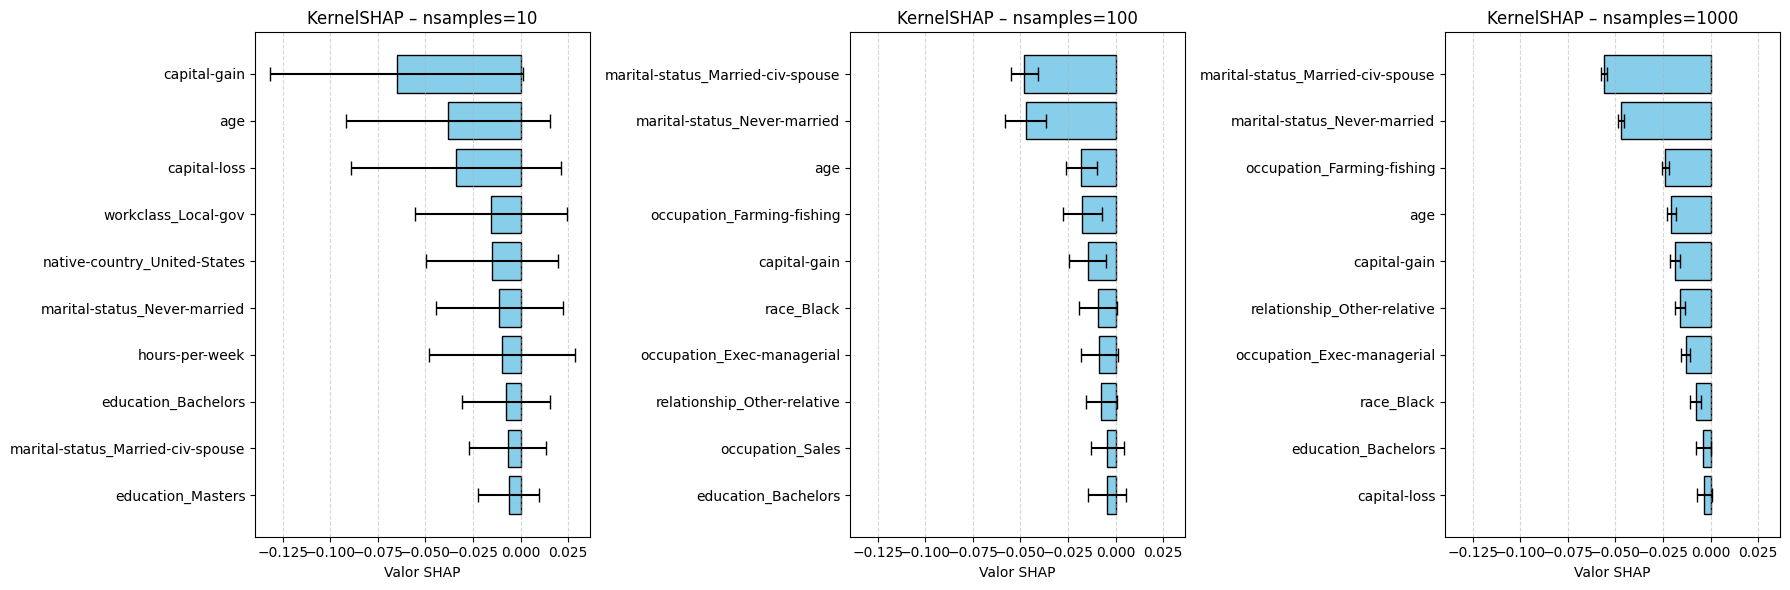

In [28]:
# Fondo reducido para velocidad
background = X_train.sample(50, random_state=10)

# Función de predicción
f = lambda x: model.predict_proba(x)

# Inicializamos el explainer
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    explainer = shap.KernelExplainer(f, background)

# Instancia a explicar (Índice 1)
x_instance = X_test.iloc[[1]]
feature_names = X_test.columns
n_features = x_instance.shape[1]

# Parámetros
nsamples_list = [10, 100, 1000]
n_runs = 10

# Estructura para guardar resultados
shap_runs = {ns: np.zeros((n_runs, n_features)) for ns in nsamples_list}

print("Iniciando análisis de sensibilidad... (esto puede tardar unos minutos)")

for ns in nsamples_list:
    print(f"  > Procesando nsamples={ns}...")
    for r in range(n_runs):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            output = explainer.shap_values(x_instance, nsamples=ns, silent=True)

        if isinstance(output, list):
            if len(output) > 1:
                vals = output[1]
            else:
                vals = output[0]
        else:
            vals = output

        if vals.shape[0] == 1:
            vals = vals[0]

        if vals.ndim == 2 and vals.shape[1] >= 2:
            vals = vals[:, 1]

        shap_runs[ns][r, :] = vals

stats_per_ns = {}

for ns in nsamples_list:
    vals = shap_runs[ns]
    mean_vals = vals.mean(axis=0)
    std_vals  = vals.std(axis=0)

    # Ordenamos por magnitud media descendente
    order = np.argsort(np.abs(mean_vals))[::-1]

    stats_per_ns[ns] = {
        "mean": mean_vals[order],
        "std":  std_vals[order],
        "names": feature_names[order]
    }

# Visualización
top_k = 10
fig, axes = plt.subplots(1, len(nsamples_list), figsize=(18, 6), sharex=True)

if len(nsamples_list) == 1: axes = [axes]

for ax, ns in zip(axes, nsamples_list):
    data = stats_per_ns[ns]
    mean_vals = data["mean"][:top_k]
    std_vals  = data["std"][:top_k]
    names     = data["names"][:top_k]

    y_pos = np.arange(top_k)

    ax.barh(y_pos, mean_vals, xerr=std_vals, capsize=5, color='skyblue', edgecolor='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names)
    ax.invert_yaxis()
    ax.set_title(f"KernelSHAP – nsamples={ns}")
    ax.set_xlabel("Valor SHAP")
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Con el gráfico anterior, hemos conseguido mostrar la evolución de las estimaciones de los valores Shapley a medida que aumentamos el número de muestras (`nsamples`) utilizadas por el algoritmo KernelSHAP para aproximar la solución.
- `nsamples` = 10: podemos observar como las barras de error son gigantescas. En muchostodos los casos, la barra de error es más grande que la propia barra de color. Además, sitúa a `capital-gain` como la característica más influyente. Sin embargo, sabemos por **TreeSHAP** que esto no es cierto. Por tanto, con solo 10 muestras, el algoritmo no ha explorado suficientes combinaciones de características. El resultado es puro "ruido". Si volviesemos a ejecutar el código, el gráfico cambiaría totalmente. La explicación no es fiable.
- `nsamples` = 100: observamos una reducción de las barras de error, aunque todavía son visibles. Ahora `marital-status_Married-civ-spouse` ha saltado al primer puesto. El modelo empieza a "entender" la estructura real de los datos. Por tanto, la estimación empieza a converger hacia los valores reales, pero todavía existe cierta incertidumbre sobre la magnitud exacta de la contribución.
- `nsamples` = 1000: en este caso, las barras de error son minúsculas. Además, el orden de importancia se estabiliza, confirmando que `marital-status` (estar o no casado) es, con diferencia, el factor negativo más importante, coincidiendo con lo que vimos en **TreeSHAP**. Finalmente, podemos decir que al usar **1000 muestras**, se ha cubierto suficientemente el espacio muestral y la varianza entre ejecuciones es casi nula. Este es el resultado más robusto y preciso.

Esto evidencia el compromiso entre coste computacional y precisión, ya que para obtener explicaciones fiables con KernelSHAP en modelos agnósticos, es necesario invertir tiempo de cálculo en un muestreo suficiente.